# ZQ vs SR3 — the meeting-dated tie-out (the gate, not the trade)

The FedWatch ladder from ZQ settles, day-weighted into each SR3 reference
window, differs from the SR3 forward by `base + spread`. If the two markets
agree on the meeting-dated path, that quantity is a **constant across
contracts** on any given day (the base and the level of the SOFR−EFFR spread
are common); the cross-contract residual is the meeting-dated disagreement
plus the spread's term structure (turns).

This is the cross-market analogue of the options lab's `forward_residual_bp`:
a **gate and diagnostic**. The linear trade it implies is SERFF's basis and is
explicitly out of scope — the design conversation's Q6 rejection.

In [1]:
CONFIG = dict(
    resid_gate_bp=6.0,        # per-contract residual beyond which the day is suspect
)
CONFIG

{'resid_gate_bp': 6.0}

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.append("../../")

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

DATA = Path("../data/meeting_prob")
tie = pd.read_parquet(DATA / "tieout.parquet")
tie["as_of"] = pd.to_datetime(tie["as_of"])
print(f"tie-out rows: {len(tie)}  dates: {tie['as_of'].nunique()}  "
      f"span {tie['as_of'].min().date()} -> {tie['as_of'].max().date()}")

tie-out rows: 4030  dates: 540  span 2024-07-01 -> 2026-07-28


## The cross-contract constant test, daily

In [3]:
g = tie.groupby("as_of")["base_plus_spread_bp"]
daily = pd.DataFrame({
    "median_bp": g.median(),
    "spread_across_contracts_bp": g.apply(lambda s: s.max() - s.min()),
    "n_contracts": g.size(),
})
tie = tie.merge(daily[["median_bp"]], on="as_of")
tie["resid_bp"] = tie["base_plus_spread_bp"] - tie["median_bp"]
print(daily.describe().round(2).to_string())

       median_bp  spread_across_contracts_bp  n_contracts
count     540.00                      540.00       540.00
mean      424.96                       12.86         7.46
std        49.68                        7.27         1.15
min       358.65                        0.00         1.00
25%       369.86                        7.77         7.00
50%       433.59                       12.11         8.00
75%       437.87                       15.55         8.00
max       537.82                       40.28         8.00


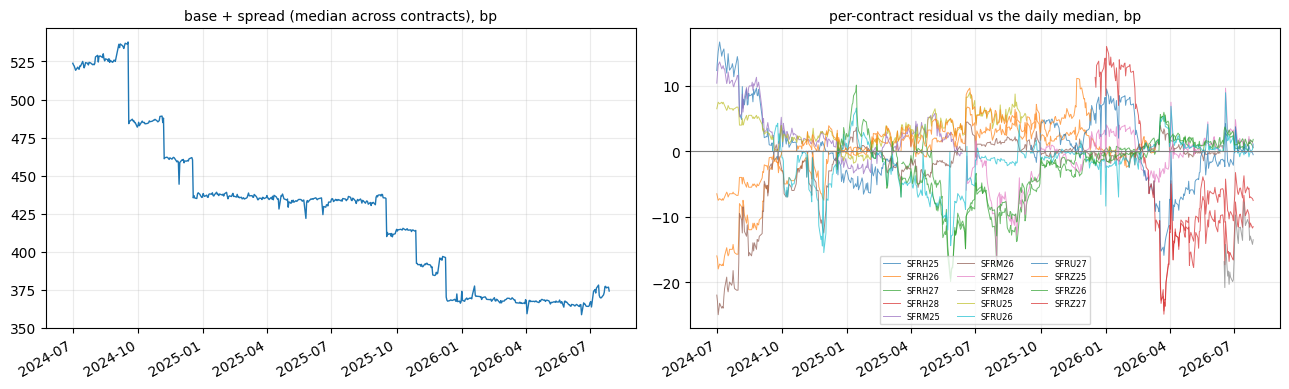

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(daily.index, daily["median_bp"], lw=1.0)
axes[0].set_title("base + spread (median across contracts), bp", fontsize=10)
axes[0].grid(alpha=0.25)
for sym, sub in tie.groupby("symbol"):
    s = sub.set_index("as_of")["resid_bp"]
    axes[1].plot(s.index, s.to_numpy(), lw=0.7, alpha=0.7, label=sym)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("per-contract residual vs the daily median, bp", fontsize=10)
axes[1].legend(fontsize=6, ncol=3)
axes[1].grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Residual anatomy

The residual's structure is informative even though it is not the trade:
a maturity pattern is the spread's term structure (and the year-end turn for
windows containing Dec 31); a common blowout is a data problem, not a signal.

In [5]:
tie["contains_turn"] = tie["symbol"].str.contains("Z2")   # Dec windows
print("residual by contract (bp):")
print(tie.groupby("symbol")["resid_bp"].describe().round(2).to_string())
print("\nresidual by turn-in-window:")
print(tie.groupby("contains_turn")["resid_bp"].describe().round(2).to_string())

residual by contract (bp):
        count   mean    std    min    25%    50%    75%    max
symbol                                                        
SFRH25  177.0   1.89   5.94  -6.56  -2.06   0.00   4.84  16.72
SFRH26  427.0  -0.81   4.98 -18.00  -1.50   0.50   2.24   6.76
SFRH27  341.0  -2.85   4.90 -19.45  -5.69  -1.22   0.50   5.55
SFRH28   95.0 -12.79   3.91 -24.93 -15.18 -11.75 -10.50  -4.50
SFRM25  240.0   3.02   4.02  -3.44   0.63   2.07   4.29  13.67
SFRM26  490.0  -2.31   5.49 -25.00  -2.51  -0.37   0.43   4.46
SFRM27  290.0  -1.30   3.96 -16.95  -3.30  -0.26   1.28   9.66
SFRM28   30.0 -14.25   3.80 -20.85 -17.97 -13.57 -11.43  -7.75
SFRU25  302.0   3.49   2.36  -1.82   1.98   3.34   5.35   8.98
SFRU26  485.0  -1.65   3.57 -15.50  -2.57  -0.95   0.38   8.96
SFRU27  225.0  -0.08   5.49 -15.93  -3.19   0.10   4.20   9.54
SFRZ25  366.0   1.94   3.86  -7.50   0.00   2.66   4.62  11.15
SFRZ26  402.0  -2.21   4.86 -19.95  -4.96  -1.03   1.30  10.12
SFRZ27  160.0  -3.11  10.40 

In [6]:
gate = (tie.groupby("as_of")["resid_bp"]
        .apply(lambda s: s.abs().max() <= CONFIG["resid_gate_bp"])
        .rename("tieout_ok"))
print(f"days passing the +/-{CONFIG['resid_gate_bp']}bp gate: "
      f"{gate.mean():.1%} of {len(gate)}")
stale_days = tie.groupby("as_of")["any_stale"].any()
print(f"days with a stale ZQ print inside a window: {stale_days.mean():.1%}")
gate.to_frame().assign(any_stale=stale_days).reset_index().to_parquet(
    DATA / "tieout_gate.parquet", index=False)
print("wrote tieout_gate.parquet")

days passing the +/-6.0bp gate: 35.4% of 540
days with a stale ZQ print inside a window: 0.0%
wrote tieout_gate.parquet
